In [1]:
#! /usr/bin/env python3
import numpy as np
import corner
import matplotlib.pyplot as plt
import h5py
from scipy.stats import norm


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import gaussian_kde
from matplotlib.colors import Normalize
from matplotlib import cm



def demo_con_style(ax, text, theta1, theta2, linecolor, connectionstyle):
    x1, y1 = theta1
    x2, y2 = theta2

    # ax.plot([x1, x2], [y1, y2], ".")
    ax.annotate(text,
                xy=(x1, y1), xycoords='data',
                xytext=(x2, y2), textcoords='data',fontsize=22,
                arrowprops=dict(arrowstyle="-", color=linecolor,linewidth=2,
                                shrinkA=15, shrinkB=2,
                                patchA=None, patchB=None,
                                connectionstyle=connectionstyle,
                                ),
                )

def joint_hist_dry(x, y, ax, ax_histx, ax_histy):
    # Disable labels and ticks on the appropriate sides
    ax_histx.tick_params(axis="x", labelbottom=False, labelleft=False, left=False)
    ax_histx.tick_params(axis="y", labelleft=False, left=False)

    ax_histy.tick_params(axis="y", labelleft=False, left=False, labelright=False, right=True)
    ax_histy.tick_params(axis="x", labelbottom=False, bottom=False)

    ax.tick_params(axis="y", labelleft=False, left=False, labelright=True, right=True)



    # Create grid for contour plot
    x_grid = np.linspace(np.min(x), np.max(x), 100)
    y_grid = np.linspace(np.min(y), np.max(y), 100)
    X, Y = np.meshgrid(x_grid, y_grid)
    Z = gaussian_kde(np.vstack([x, y]))(np.vstack([X.ravel(), Y.ravel()])).reshape(X.shape)

    # Create a custom colormap using the first half of 'bwr_r'
    original_cmap = cm.get_cmap('bwr')
    custom_cmap = original_cmap(np.linspace(0.5, 0, 256))  # Extract the first half
    custom_cmap = cm.colors.ListedColormap(custom_cmap)

    # Plot contours using the custom colormap
    cont = ax.contourf(X, Y, Z, levels=100, cmap=custom_cmap, alpha=1)

    X, Y = np.meshgrid(x_grid, y_grid)
    kde = gaussian_kde([x, y])
    mean = [np.mean(x), np.mean(y)]
    cov = np.cov(x, y)

    from scipy.stats import multivariate_normal
    levels = [multivariate_normal.pdf(mean, mean=mean, cov=cov) * 0.6065306597,  # ~1 std dev
            multivariate_normal.pdf(mean, mean=mean, cov=cov) * 0.1353352832,  # ~2 std dev
            multivariate_normal.pdf(mean, mean=mean, cov=cov) * 0.01110899654, # ~3 std dev
            ] 
    Z = kde(np.vstack([X.ravel(), Y.ravel()])).reshape(X.shape)
    CS = ax.contour(X, Y,Z, levels=[levels[0],],  colors=('b',), linewidths=3, alpha=1)
    CS = ax.contour(X, Y,Z, levels=[levels[1],],  colors=('b',), linewidths=3, alpha=0.5)
    CS = ax.contour(X, Y,Z, levels=[levels[2],],  colors=('b',), linewidths=3, alpha=0.3)
    # CS = ax.contour(X, Y,Z, levels=levels[::-1],  colors=((1, 0, 0,1), (1, 0, 0,0.7), (1, 0, 0, 0.5)), linewidths=2)


    demo_con_style(ax, "39.3%       ",  [379.8-20,178.4-1.3], [345-20,181-1.3], "k","arc,angleA=0,angleB=-90,armA=150,rad=0")
    demo_con_style(ax, "86.5%       ", [370-20-0.2-0.4,178-1.2], [341-20,179-1.3], "k","arc,angleA=0,angleB=-90,armA=130,rad=0")
    ax.text(338-20,177-1.3, "98.9%",fontsize=22)

    ax_histx.hist(x, bins=30, density=True, color="Navy", alpha=1, histtype='step', linewidth=3)
    ax_histy.hist(y, bins=30, density=True, color='Navy', alpha=1, histtype='step', orientation='horizontal', linewidth=3)
    ax_histy.invert_xaxis()
    ax_histy.set_xlim(0.22,0)

    means = np.mean(x)
    stdev = np.std(x)
    counts, bin_edges = np.histogram(x, bins=30, density=True)
  
    for ii in range(len(counts)):
        if bin_edges[ii]<=(means - stdev) and  bin_edges[ii+1]>=(means - stdev):
            ax_histx.fill_between([means - stdev,bin_edges[ii+1]], 0,[counts[ii],counts[ii]],  color='blue', alpha=0.5,linewidth=0)
        
    for ii in range(len(counts)):
        if bin_edges[ii]<=(means + stdev) and  bin_edges[ii+1]>=(means + stdev):
            ax_histx.fill_between([bin_edges[ii],means + stdev], 0,[counts[ii],counts[ii]],  color='blue', alpha=0.5,linewidth=0)
        
    for ii in range(len(counts)):
        if bin_edges[ii]>=(means - stdev) and  bin_edges[ii+1]<=(means + stdev):
            ax_histx.fill_between([bin_edges[ii],bin_edges[ii+1]], 0,[counts[ii],counts[ii]],  color='blue', alpha=0.5,linewidth=0)

    means = np.mean(y)
    stdev = np.std(y)
    counts, bin_edges = np.histogram(y, bins=30, density=True)
  
    for ii in range(len(counts)):
        if bin_edges[ii]<=(means - stdev) and  bin_edges[ii+1]>=(means - stdev):
            ax_histy.fill_between([counts[ii],0],means - stdev,bin_edges[ii+1], color='blue', alpha=0.5,linewidth=0)
        
    for ii in range(len(counts)):
        if bin_edges[ii]<=(means + stdev) and  bin_edges[ii+1]>=(means + stdev):
            ax_histy.fill_between([counts[ii],0],bin_edges[ii],means + stdev, color='blue', alpha=0.5,linewidth=0)
        
    for ii in range(len(counts)):
        if bin_edges[ii]>=(means - stdev) and  bin_edges[ii+1]<=(means + stdev):
            ax_histy.fill_between([counts[ii],0],bin_edges[ii],bin_edges[ii+1], color='blue', alpha=0.5,linewidth=0)



In [3]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import gaussian_kde
from matplotlib import cm

def joint_hist_moist(x, y, ax, ax_histx, ax_histy):
    # Disable labels and ticks on the appropriate sides
    ax_histx.tick_params(axis="x", labelbottom=False, labelleft=False, left=False)
    ax_histx.tick_params(axis="y", labelleft=False, left=False)

    ax_histy.tick_params(axis="y", labelleft=False, left=True, labelright=False, right=False)
    ax_histy.tick_params(axis="x", labelbottom=False, bottom=False)
    # ax_histy.invert_xaxis()

    ax.tick_params(axis="y", labelleft=True, left=True, labelright=False, right=False)

    # ax.scatter(x, y, c='blue', s=1., alpha=0.5)

    # Create grid for contour plot
    x_grid = np.linspace(np.min(x), np.max(x), 100)
    y_grid = np.linspace(np.min(y), np.max(y), 100)
    X, Y = np.meshgrid(x_grid, y_grid)
    Z = gaussian_kde(np.vstack([x, y]))(np.vstack([X.ravel(), Y.ravel()])).reshape(X.shape)

    # Create a custom colormap using the first half of 'bwr_r'
    original_cmap = cm.get_cmap('bwr')
    custom_cmap = original_cmap(np.linspace(0.5, 0, 256))  # Extract the first half
    custom_cmap = cm.colors.ListedColormap(custom_cmap)

    # Plot contours using the custom colormap
    cont = ax.contourf(X, Y, Z, levels=100, cmap=custom_cmap, alpha=1)


    X, Y = np.meshgrid(x_grid, y_grid)
    kde = gaussian_kde([x, y])
    mean = [np.mean(x), np.mean(y)]
    cov = np.cov(x, y)

    from scipy.stats import multivariate_normal
    levels = [multivariate_normal.pdf(mean, mean=mean, cov=cov) * 0.6065306597,  # ~1 std dev
            multivariate_normal.pdf(mean, mean=mean, cov=cov) * 0.1353352832,  # ~2 std dev
            multivariate_normal.pdf(mean, mean=mean, cov=cov) * 0.011, # ~3 std dev
            ] 
    Z = kde(np.vstack([X.ravel(), Y.ravel()])).reshape(X.shape)
    CS = ax.contour(X, Y,Z, levels=[levels[0],],  colors=('b',), linewidths=3, alpha=1)
    CS = ax.contour(X, Y,Z, levels=[levels[1],],  colors=('b',), linewidths=3, alpha=0.5)
    CS = ax.contour(X, Y,Z, levels=[levels[2],],  colors=('b',), linewidths=3, alpha=0.3)
    # CS = ax.contour(X, Y,Z, levels=levels[::-1],  colors=((1, 0, 0,1), (1, 0, 0,0.7), (1, 0, 0, 0.5)), linewidths=2)


    # demo_con_style(ax, "39.3%",  [3,178.4], [3.2,181], "k","arc,angleA=0,angleB=-90,armA=120,rad=0")
    # demo_con_style(ax, "86.5%", [3,178], [3.2,179], "blue","arc,angleA=0,angleB=-90,armA=120,rad=0")
    ax.text(2.8,175.3, "39.3%",fontsize=22)
    ax.text(3.6,176.5, "86.5%",fontsize=22)
    ax.text(4.3,177.7, "98.9%",fontsize=22)



    ax_histx.hist(x, bins=30, linewidth=3, density=True, color="Navy", alpha=1, histtype='step')
    ax_histy.hist(y, bins=30, linewidth=3, density=True, color='Navy', alpha=1, histtype='step', orientation='horizontal')

    # ax_histy.set_xlim(0.22,0)


    means = np.median(x)
    stdev = np.std(x)
    counts, bin_edges = np.histogram(x, bins=30, density=True)
  
    for ii in range(len(counts)):
        if bin_edges[ii]<=(means - stdev) and  bin_edges[ii+1]>=(means - stdev):
            ax_histx.fill_between([means - stdev,bin_edges[ii+1]], 0,[counts[ii],counts[ii]],  color='blue', alpha=0.5,linewidth=0)
        
    for ii in range(len(counts)):
        if bin_edges[ii]<=(means + stdev) and  bin_edges[ii+1]>=(means + stdev):
            ax_histx.fill_between([bin_edges[ii],means + stdev], 0,[counts[ii],counts[ii]],  color='blue', alpha=0.5,linewidth=0)
        
    for ii in range(len(counts)):
        if bin_edges[ii]>=(means - stdev) and  bin_edges[ii+1]<=(means + stdev):
            ax_histx.fill_between([bin_edges[ii],bin_edges[ii+1]], 0,[counts[ii],counts[ii]],  color='blue', alpha=0.5,linewidth=0)

    means = np.mean(y)
    stdev = np.std(y)
    counts, bin_edges = np.histogram(y, bins=30, density=True)
  
    for ii in range(len(counts)):
        if bin_edges[ii]<=(means - stdev) and  bin_edges[ii+1]>=(means - stdev):
            ax_histy.fill_between([counts[ii],0],means - stdev,bin_edges[ii+1], color='blue', alpha=0.5,linewidth=0)
        
    for ii in range(len(counts)):
        if bin_edges[ii]<=(means + stdev) and  bin_edges[ii+1]>=(means + stdev):
            ax_histy.fill_between([counts[ii],0],bin_edges[ii],means + stdev, color='blue', alpha=0.5,linewidth=0)
        
    for ii in range(len(counts)):
        if bin_edges[ii]>=(means - stdev) and  bin_edges[ii+1]<=(means + stdev):
            ax_histy.fill_between([counts[ii],0],bin_edges[ii],bin_edges[ii+1], color='blue', alpha=0.5,linewidth=0)




[10000, 12, 5]


/tmp/ipykernel_488733/3231029623.py:43: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  original_cmap = cm.get_cmap('bwr')


[10000, 8, 3]
(7000, 8)


/tmp/ipykernel_488733/792573446.py:26: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  original_cmap = cm.get_cmap('bwr')


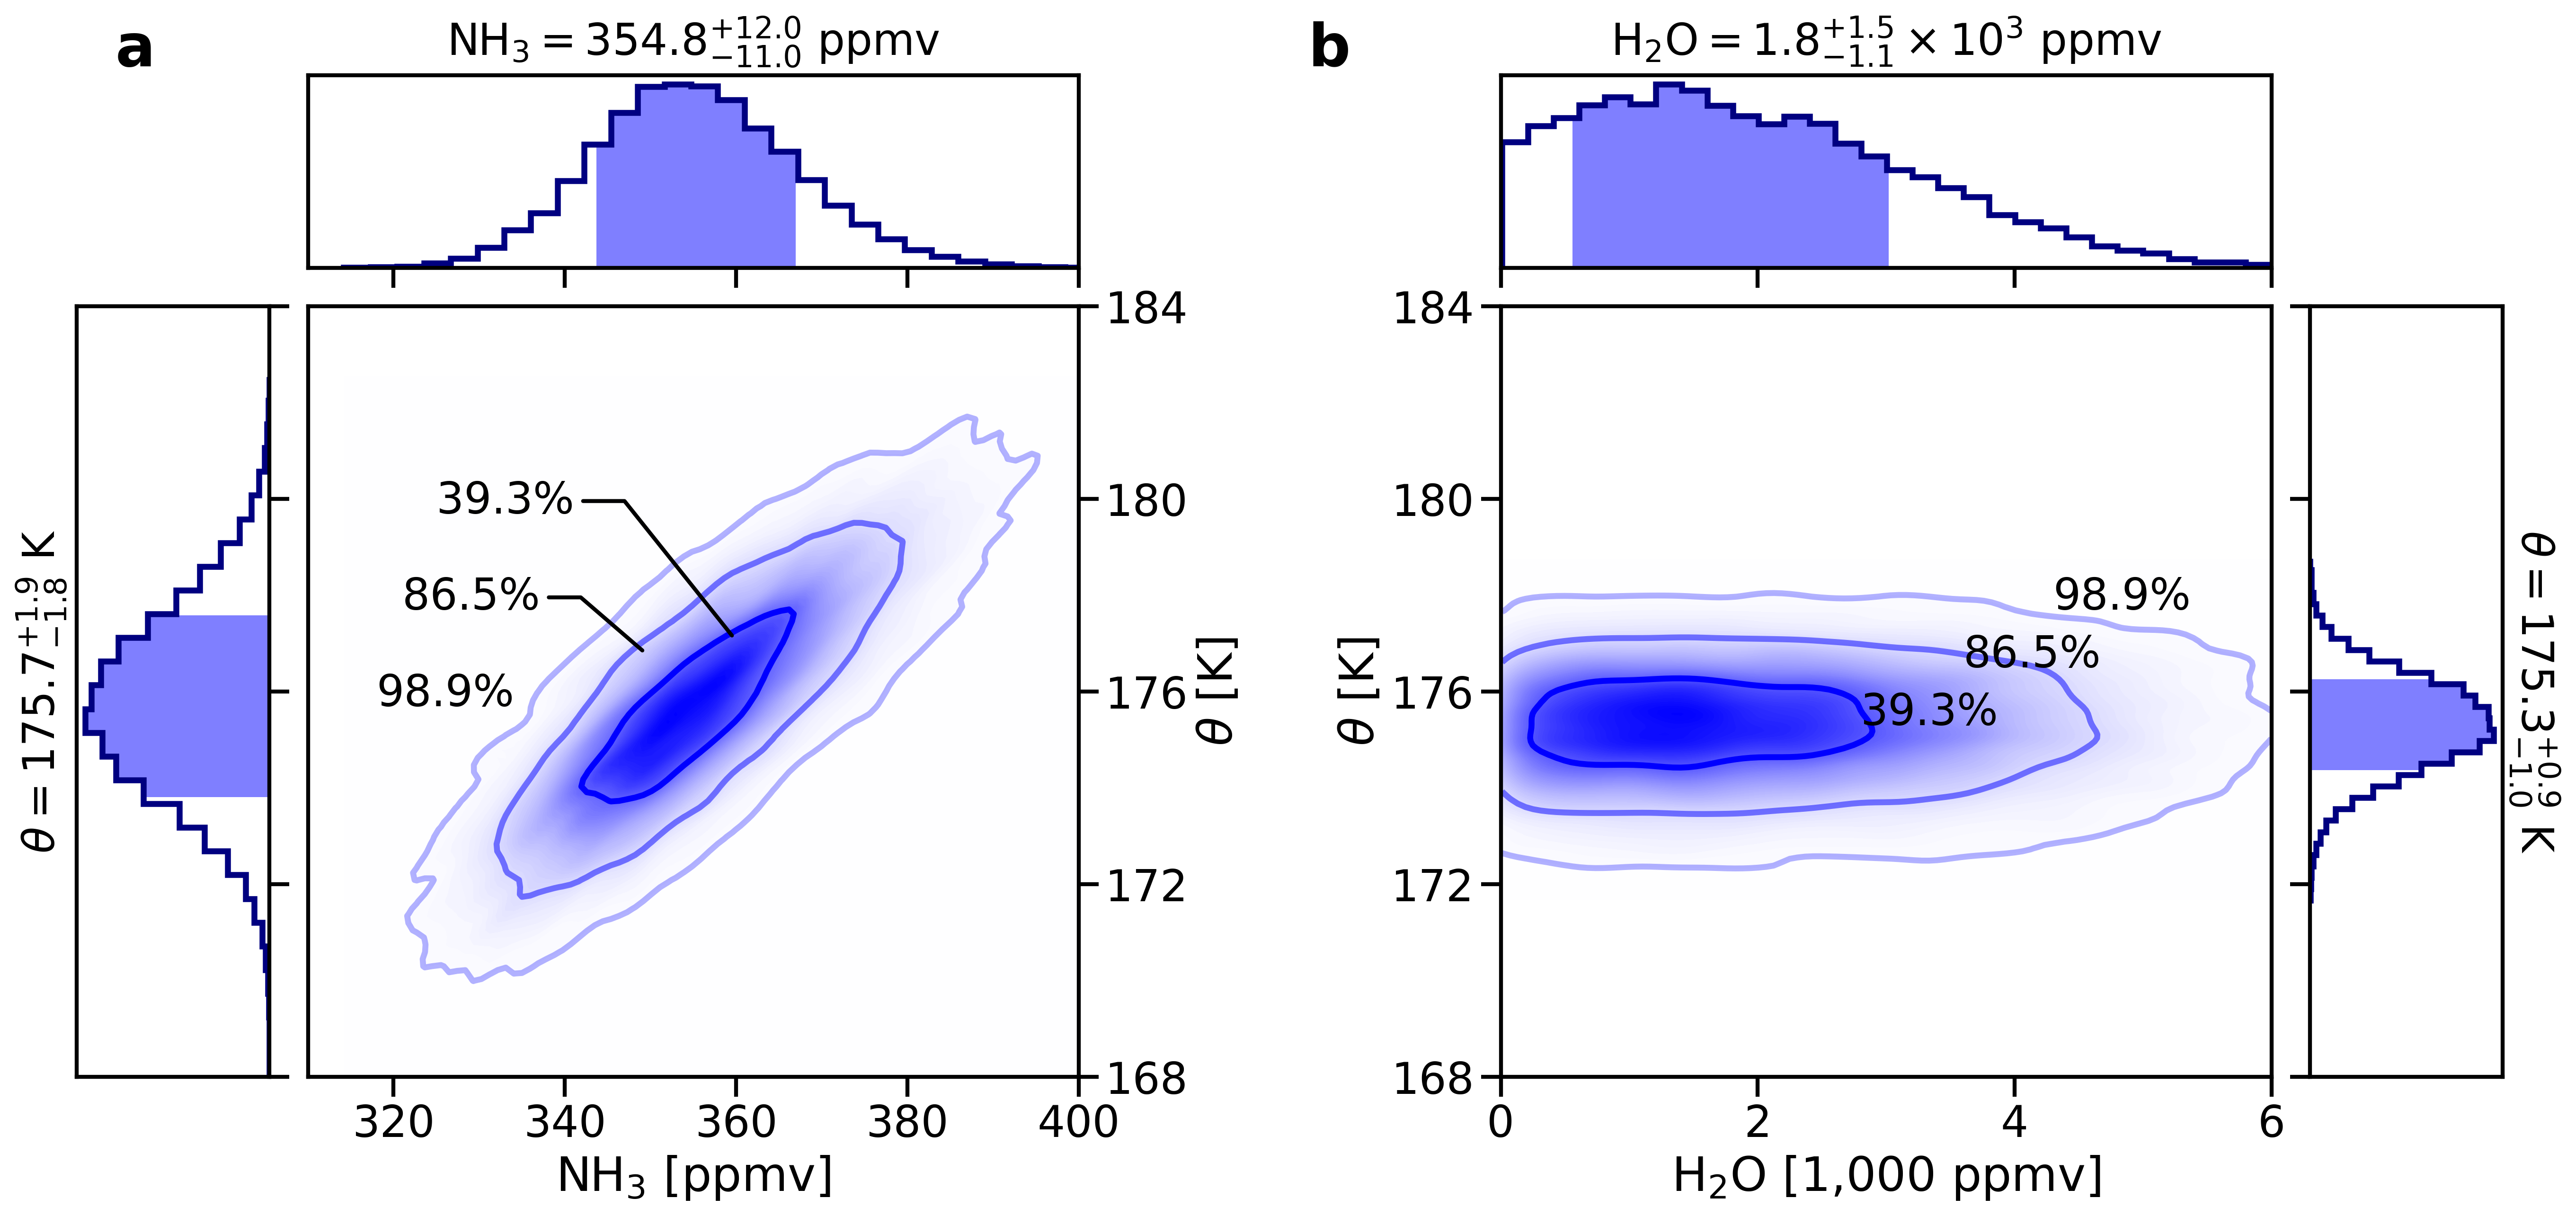

In [5]:
fig, [ax1, ax2] = plt.subplots(1,2,figsize=(19,9),dpi=300)


## ax1 for the dry case
h5=h5py.File(f'../dry_adiab/redo_emcee_dryadiab_depletedNH3_FabianoLD_parallel_10000.h5', 'r') 

chain = h5['mcmc']['chain'][:,:,:]
[nstep,nwalk,ndim]=chain.shape
print([nstep,nwalk,ndim])
h5.close()
chain[:, :, ndim-1]*=1E-5  ## pa -> bar
labels=["qNH3 [ppm]", "Temperature [K]", "RH_max_NH3","adlnNH3dlnP","Pmax [bar]"]

flattened_chain = chain[3000:,:,:].reshape(-1,5)

x=flattened_chain[:, 0]
y=flattened_chain[:, 1]

# Calculate the 16th and 84th percentiles
mmx = np.percentile(x, 50)
lowerx = np.percentile(x, 16)
upperx = np.percentile(x, 84)

mmy = np.percentile(y, 50)
lowery = np.percentile(y, 16)
uppery = np.percentile(y, 84)

ax = ax1
# Create the main scatter plot axes
# ax = fig.add_gridspec(top=0.75, left=0.75).subplots()
# ax.set(aspect=1)
ax.set(aspect=5.625) 
# Create marginal histograms for x and y axes
ax_histx = ax.inset_axes([0, 1.05, 1, 0.25], sharex=ax)
ax_histy = ax.inset_axes([-0.3, 0, 0.25, 1], sharey=ax)

ax.set_xlim(310, 400)
ax.set_ylim(168,184)

ax.set_yticks([168, 172,176,180,184])
ax.set_xticks([320,340,360,380,400])

ax.set_xlabel(r'$\text{NH}_3$ [ppmv]',fontsize=24)
ax.set_ylabel(r'$\theta$ [K]',fontsize=24)
ax.yaxis.set_label_position("right")

ax_histx.set_xlabel(rf"NH$_3={mmx:.1f}_{{{lowerx-mmx:.1f}}}^{{+{upperx-mmx:.1f}}}$ ppmv",labelpad=10,fontsize=22)
ax_histy.set_ylabel(rf"$\theta={mmy:.1f}_{{{lowery-mmy:.1f}}}^{{+{uppery-mmy:.1f}}}$ K", fontsize=22)

ax_histx.xaxis.set_label_position("top")
ax_histy.yaxis.set_label_position("left")

# Draw the density plot and marginal histograms
joint_hist_dry(x, y, ax, ax_histx, ax_histy)
ax_histx.text(-0.25, 1.37, "a", fontsize=30, fontweight='bold', va='top', ha='left', transform=ax.transAxes)

for ax in [ax, ax_histx, ax_histy]:
    for axis in ['top','bottom','left','right']:
        ax.spines[axis].set_linewidth(2)
    ax.tick_params(which='major', length=10, width=2, labelsize=22)
    ax.tick_params(which='minor', length=5, width=2)


##===================================================
##            ax2 for the moist case
##===================================================
h5=h5py.File(f'../moist_adiab/redo_emcee_moistadiab_FabianoLD_parallel_10000.h5', 'r') 
chain = h5['mcmc']['chain'][:,:,:]
[nstep,nwalk,ndim]=chain.shape
print([nstep,nwalk,ndim])
h5.close()

labels=["qNH3 [ppm]", "Temperature [K]", "RH_max_NH3"]
flattened_chain = chain[3000:,:,:].reshape(-1,3)
x=flattened_chain[:, 0]*1E-3  # 1000 ppm
# y=flattened_chain[:, 1]

h5=h5py.File('../moist_adiab/reconstruct_temp_to_deeptheta_10000.h5', 'r') 
deeptheta = h5['PotentialTemperature'][3000:,:]
print(deeptheta.shape)
h5.close()
y=deeptheta.flatten()

# Calculate the 16th and 84th percentiles
mmx = np.percentile(x, 50)
lowerx = np.percentile(x, 16)
upperx = np.percentile(x, 84)

mmy = np.percentile(y, 50)
lowery = np.percentile(y, 16)
uppery = np.percentile(y, 84)

ax = ax2
# Create the main scatter plot axes
# ax = fig.add_subplot(111)
# ax.set(aspect=1)
ax.set(aspect=6/16) 
# Create marginal histograms for x and y axes
ax_histx = ax.inset_axes([0, 1.05, 1, 0.25], sharex=ax)
ax_histy = ax.inset_axes([1.05, 0, 0.25, 1], sharey=ax)

ax.set_xlim(0,6)
ax.set_ylim(168,184)
ax.set_yticks([168, 172,176,180,184])

ax.set_xlabel(r'$\text{H}_2$O [1,000 ppmv]',fontsize=24)
ax.set_ylabel(r'$\theta$ [K]',fontsize=24)
ax.yaxis.set_label_position("left")

ax_histx.text(-0.25, 1.37, "b", fontsize=30, fontweight='bold', va='top', ha='left', transform=ax.transAxes)

ax_histx.set_xlabel(rf"H$_2$O$={mmx:.1f}_{{{lowerx-mmx:.1f}}}^{{+{upperx-mmx:.1f}}} \times 10^3$ ppmv",labelpad=10,fontsize=22)
ax_histy.set_ylabel(rf"$\theta={mmy:.1f}_{{{lowery-mmy:.1f}}}^{{+{uppery-mmy:.1f}}}$ K", rotation=-90,labelpad=30, fontsize=22)

ax_histx.xaxis.set_label_position("top")
ax_histy.yaxis.set_label_position("right")

# Draw the density plot and marginal histograms
joint_hist_moist(x, y, ax, ax_histx, ax_histy)

for ax in [ax, ax_histx, ax_histy]:
    for axis in ['top','bottom','left','right']:
        ax.spines[axis].set_linewidth(2)
    ax.tick_params(which='major', length=10, width=2, labelsize=22)
    ax.tick_params(which='minor', length=5, width=2)

plt.tight_layout()
plt.savefig('fig3.pdf', dpi=300)
# plt.show()
